In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA

In [3]:
path = kagglehub.dataset_download("uciml/red-wine-quality-cortez-et-al-2009")
# pega do kaggle um dataset
df = pd.read_csv(f"{path}/winequality-red.csv")

In [4]:
df.head()
# peag as 5 primeiras linhas


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
df.shape

(1599, 12)

In [6]:
df.isnull().sum()
# verifica se existe algum nulo

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [7]:
x = df[['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar','chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density','pH', 'sulphates', 'alcohol']]
# pega as features que serao usadas para prever a quality
x

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2


In [8]:
y = df['quality']
# feature target

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)
# separa em dados de treino e teste, 70% para trino e 30% para teste

In [10]:
scaler = StandardScaler()
x_train_scale = scaler.fit_transform(x_train)
x_test_scale = scaler.transform(x_test)
# normaliza os dados para simplificar os dados

In [11]:
pca = PCA(n_components=8, whiten=True).fit(x_train_scale)
# transforma as 11 features em 8, o pca transforma e relaciona os dados pra 'compacta-los'
x_train_pca = pca.transform(x_train_scale)
x_test_pca = pca.transform(x_test_scale)
# aplica a transformação de features para o treino e teste

In [12]:
list_acuracias = []
for k in range(1, 201, 10):
    model = KNeighborsClassifier(n_neighbors=k)
    model = model.fit(x_train_pca, y_train)
    # treina o modelo com as features reduzidas no pca e o target original
    predict = model.predict(x_test_pca)
    # predicao usando oa dadoa do treino
    list_acuracias.append(accuracy_score(y_test, predict))
    # calcula a acuracia comparando com as respostas certas


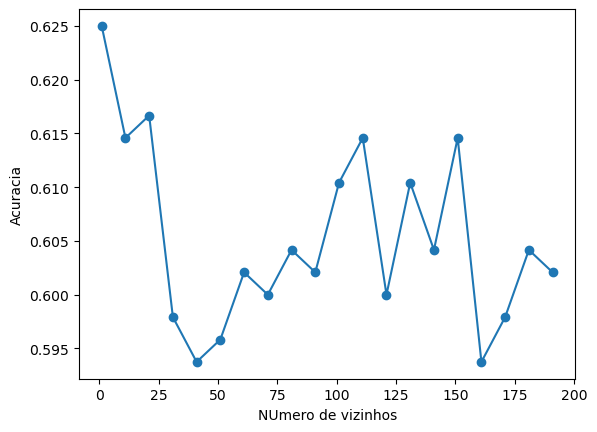

In [13]:
plt.plot(range(1,201,10),list_acuracias, marker='o')
plt.xlabel("NUmero de vizinhos")
plt.ylabel("Acuracia")
plt.savefig("num_vizinhos_acuracia.png", dpi=150)
plt.show()

In [16]:
max(list_acuracias)


0.625

In [20]:
list_acuracias[2]

0.6166666666666667

### Resultado pessimo, o modelo é muito fraco e nao consegue achar padroes especificos nos dados